<a href="https://colab.research.google.com/github/LailaBulh/Procesamiento_Lenguaje_Natural/blob/main/Etiquetado_gramatical_LB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Etiquetado gramatical**

**Nombre:** Laila Montserrat Bulhosen Ramos **Matrícula**: 263166

**Docente:** Dr. Rogelio Florencia Juarez

**Materia:** Procesamiento de Lenguaje Natural



**Link Github:** [Etiquetado_gramatical_LB](https://github.com/LailaBulh/Procesamiento_Lenguaje_Natural/blob/main/Etiquetado_gramatical_LB.ipynb)

**Fecha:** Mayor 2026


### **Objetivo:** Aplicar conceptos de etiquetado gramatical mediante el análisis de un texto en español y realizar un análisis exploratorio de datos a partir de las etiquetas obtenidas.

In [1]:
texto = '''En los últimos años, muchas universidades han incorporado herramientas digitales para apoyar el aprendizaje de los estudiantes.
Estas tecnologías permiten organizar materiales, facilitar la comunicación y ofrecer actividades interactivas dentro y fuera del aula.
Sin embargo, su uso no siempre garantiza mejores resultados académicos, porque también depende de la planeación del docente y del compromiso del alumno.
En algunos cursos, los estudiantes participan más cuando utilizan plataformas virtuales, foros o sistemas de retroalimentación inmediata.
Además, los profesores pueden analizar con mayor facilidad el avance del grupo y detectar dificultades en temas específicos. Por esta razón,
el uso de recursos tecnológicos se ha convertido en un tema relevante para la educación actual.'''

print(texto)

En los últimos años, muchas universidades han incorporado herramientas digitales para apoyar el aprendizaje de los estudiantes. 
Estas tecnologías permiten organizar materiales, facilitar la comunicación y ofrecer actividades interactivas dentro y fuera del aula. 
Sin embargo, su uso no siempre garantiza mejores resultados académicos, porque también depende de la planeación del docente y del compromiso del alumno. 
En algunos cursos, los estudiantes participan más cuando utilizan plataformas virtuales, foros o sistemas de retroalimentación inmediata. 
Además, los profesores pueden analizar con mayor facilidad el avance del grupo y detectar dificultades en temas específicos. Por esta razón, 
el uso de recursos tecnológicos se ha convertido en un tema relevante para la educación actual.


## **Importación de Librerias**

In [13]:
import re
import nltk
from nltk.tag import hmm
from nltk.corpus import cess_esp
#from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

import spacy


In [3]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

## **1. Dividir el texto en tokens**

In [4]:
### Convertir a minusculas

texto_min = texto.lower()

print(texto_min)

en los últimos años, muchas universidades han incorporado herramientas digitales para apoyar el aprendizaje de los estudiantes. 
estas tecnologías permiten organizar materiales, facilitar la comunicación y ofrecer actividades interactivas dentro y fuera del aula. 
sin embargo, su uso no siempre garantiza mejores resultados académicos, porque también depende de la planeación del docente y del compromiso del alumno. 
en algunos cursos, los estudiantes participan más cuando utilizan plataformas virtuales, foros o sistemas de retroalimentación inmediata. 
además, los profesores pueden analizar con mayor facilidad el avance del grupo y detectar dificultades en temas específicos. por esta razón, 
el uso de recursos tecnológicos se ha convertido en un tema relevante para la educación actual.


In [5]:
### Eliminar puntuaciones

txt_punct = re.sub(r'[^\w\s]', '', texto_min)

print(txt_punct)

en los últimos años muchas universidades han incorporado herramientas digitales para apoyar el aprendizaje de los estudiantes 
estas tecnologías permiten organizar materiales facilitar la comunicación y ofrecer actividades interactivas dentro y fuera del aula 
sin embargo su uso no siempre garantiza mejores resultados académicos porque también depende de la planeación del docente y del compromiso del alumno 
en algunos cursos los estudiantes participan más cuando utilizan plataformas virtuales foros o sistemas de retroalimentación inmediata 
además los profesores pueden analizar con mayor facilidad el avance del grupo y detectar dificultades en temas específicos por esta razón 
el uso de recursos tecnológicos se ha convertido en un tema relevante para la educación actual


In [14]:
### Tokenizacion

tokens = word_tokenize(txt_punct)

print(f'Texto tokenizado: \n{tokens}')


Texto tokenizado: 
['en', 'los', 'últimos', 'años', 'muchas', 'universidades', 'han', 'incorporado', 'herramientas', 'digitales', 'para', 'apoyar', 'el', 'aprendizaje', 'de', 'los', 'estudiantes', 'estas', 'tecnologías', 'permiten', 'organizar', 'materiales', 'facilitar', 'la', 'comunicación', 'y', 'ofrecer', 'actividades', 'interactivas', 'dentro', 'y', 'fuera', 'del', 'aula', 'sin', 'embargo', 'su', 'uso', 'no', 'siempre', 'garantiza', 'mejores', 'resultados', 'académicos', 'porque', 'también', 'depende', 'de', 'la', 'planeación', 'del', 'docente', 'y', 'del', 'compromiso', 'del', 'alumno', 'en', 'algunos', 'cursos', 'los', 'estudiantes', 'participan', 'más', 'cuando', 'utilizan', 'plataformas', 'virtuales', 'foros', 'o', 'sistemas', 'de', 'retroalimentación', 'inmediata', 'además', 'los', 'profesores', 'pueden', 'analizar', 'con', 'mayor', 'facilidad', 'el', 'avance', 'del', 'grupo', 'y', 'detectar', 'dificultades', 'en', 'temas', 'específicos', 'por', 'esta', 'razón', 'el', 'uso', 

## **2. Asignación de etiquetas gramaticales**

In [25]:
### Descargar modelo en español
nlp = spacy.load("es_core_news_sm")

### Procesar la oración
doc = nlp(txt_punct)

print('Utilizando la libreria de spaCy se asignan etiquetas a cada token, obteniendo el siguiente resultado.\n')

tags = []
for token in doc:
    tags.append((token.text, token.pos_))
    print(token.text, token.pos_)


Utilizando la libreria de spaCy se asignan etiquetas a cada token, obteniendo el siguiente resultado.

en ADP
los DET
últimos ADJ
años NOUN
muchas DET
universidades NOUN
han AUX
incorporado VERB
herramientas NOUN
digitales ADJ
para ADP
apoyar VERB
el DET
aprendizaje NOUN
de ADP
los DET
estudiantes NOUN

 SPACE
estas DET
tecnologías NOUN
permiten VERB
organizar VERB
materiales ADJ
facilitar VERB
la DET
comunicación NOUN
y CCONJ
ofrecer VERB
actividades NOUN
interactivas ADJ
dentro ADV
y CCONJ
fuera ADV
del ADP
aula NOUN

 SPACE
sin ADP
embargo NOUN
su DET
uso NOUN
no ADV
siempre ADV
garantiza VERB
mejores ADJ
resultados NOUN
académicos ADJ
porque SCONJ
también ADV
depende VERB
de ADP
la DET
planeación NOUN
del ADP
docente NOUN
y CCONJ
del ADP
compromiso NOUN
del ADP
alumno NOUN

 SPACE
en ADP
algunos DET
cursos NOUN
los DET
estudiantes NOUN
participan VERB
más ADV
cuando SCONJ
utilizan VERB
plataformas NOUN
virtuales ADJ
foros NOUN
o CCONJ
sistemas NOUN
de ADP
retroalimentación NOUN
inm

## **3. Análisis exploratorio de los datos**

### **Número total de tokens**

In [22]:
total_tokens = len(tokens)

print(f'El total de tokens encontrados en el texto es: {total_tokens}')

El total de tokens encontrados en el texto es: 111


### **Número total de tokens distintos**

In [24]:
total_distinct = len(set(tokens))

print(f'El total de tokens únicos en el texto es: {total_distinct}')

El total de tokens únicos en el texto es: 88


### **Conteo de cada categoría gramatical**

In [50]:
### Se crea un dataframe para almacenar los datos de cada categoria gramatical y su cuenta
tags_df = pd.DataFrame(columns=['Tag', 'Conteo'])

### Ciclo for para iterar en cada item de la lista y contar frecuencia
for categoria in tags:
  i = 0
  for tag in tags:
    if categoria[1] == tag[1]:
      i += 1
  tags_df.loc[len(tags_df)] = [categoria[1], i]

print('Muestra de la cuenta total por etiqueta')
tags_df.head(10)

Muestra de la cuenta total por etiqueta


,Tag,Conteo
0,ADP,18
1,DET,16
2,ADJ,13
3,NOUN,33
4,DET,16
5,NOUN,33
6,AUX,3
7,VERB,13
8,NOUN,33
9,ADJ,13


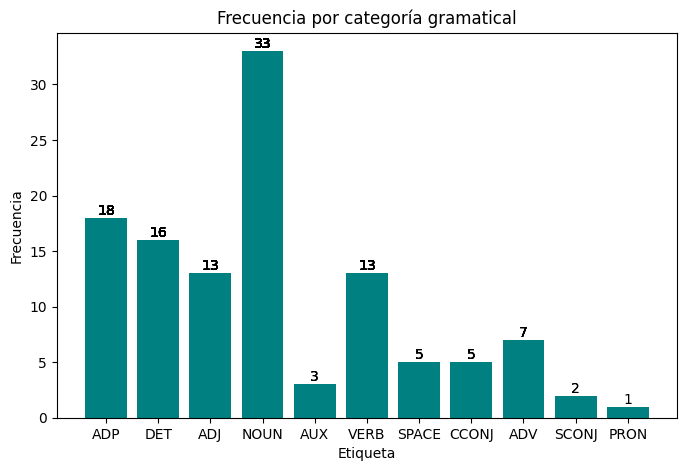

In [57]:
import matplotlib.pyplot as plt

### Grafica de barras

plt.figure(figsize=(8,5))
bars = plt.bar(tags_df['Tag'], tags_df['Conteo'], color=['teal'])

# Ciclo for para agregar frecuencia sobrecada barra
for bar in bars:
    altura = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        altura,
        str(altura),
        ha='center', va='bottom'
    )

### plot
plt.xlabel("Etiqueta")
plt.ylabel("Frecuencia")
plt.title("Frecuencia por categoría gramatical")
plt.show()


### **Top 5 de tokens**

### **Clases gramaticales**